# Exercise: Exact Rejection Sampling

## The Coin-Flipping Problem

We observe **7 heads in 10 coin flips**. We want to infer $p$, the true probability of heads.

- **Prior**: $p \sim \text{Beta}(1, 1)$ — a uniform prior (we know nothing a priori)
- **Likelihood**: $x \mid p \sim \text{Binomial}(n=10,\, p)$
- **Observed data**: $x_{\text{obs}} = 7$

The **analytical posterior** is $p \mid x_{\text{obs}} \sim \text{Beta}(1 + 7,\, 1 + 3) = \text{Beta}(8, 4)$.

We will recover this using (exact) rejection sampling.

---
## Imports

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)   # reproducible results
print("Libraries loaded")

Libraries loaded


---
## Running Rejection Sampling

In [13]:
N = 5000          # number of prior samples
observed = 7      # observed number of heads

# Step 1: Sample from the prior  p ~ Beta(1, 1)
prior = np.random.beta(1, 1, size=N)

# Step 2: Simulate data from the likelihood  x ~ Binomial(10, p)
x = np.random.binomial(n=10, p=prior)

# Step 3: Keep only samples where simulated data matches the observation
posterior = prior[x == observed]

print(f"Total prior samples  : {N}")
print(f"Accepted samples     : {len(posterior)}")
print(f"Acceptance rate      : {len(posterior)/N:.1%}")

Total prior samples  : 5000
Accepted samples     : 491
Acceptance rate      : 9.8%


---
## Visualise the Results

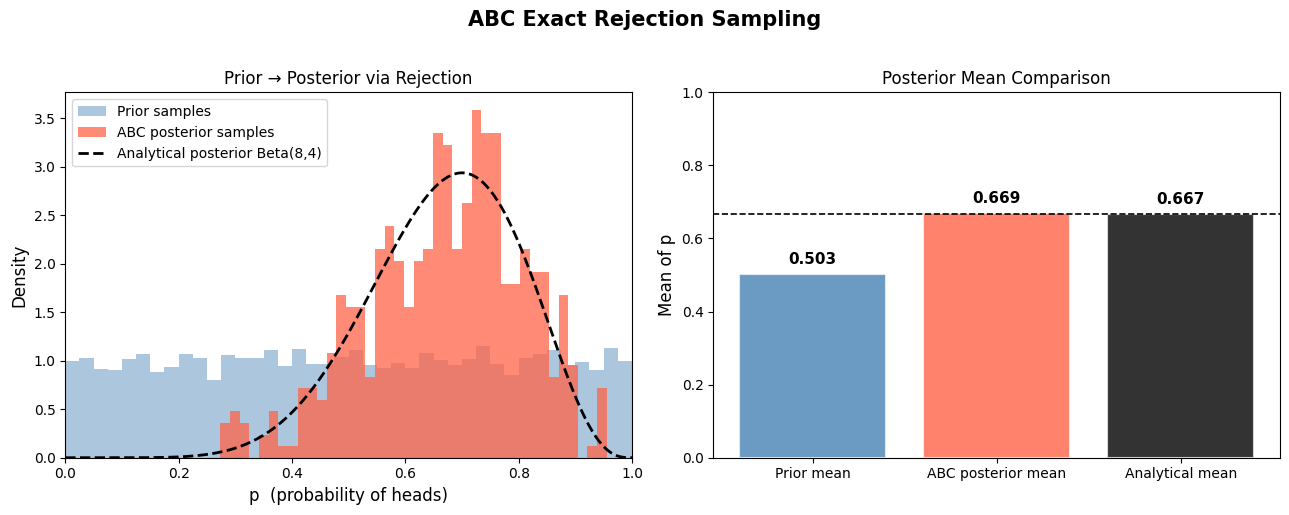

In [14]:
# Analytical posterior: Beta(1 + 7, 1 + 3) = Beta(8, 4)
p_grid = np.linspace(0, 1, 300)
analytical = stats.beta(8, 4).pdf(p_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ABC Exact Rejection Sampling", fontsize=15, fontweight="bold", y=1.02)

# --- Left panel: prior vs posterior samples ---
ax = axes[0]
ax.hist(prior,     bins=40, density=True, alpha=0.45, color="steelblue", label="Prior samples")
ax.hist(posterior, bins=40, density=True, alpha=0.75, color="tomato",    label="ABC posterior samples")
ax.plot(p_grid, analytical, "k--", linewidth=2, label="Analytical posterior Beta(8,4)")
ax.set_xlabel("p  (probability of heads)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Prior → Posterior via Rejection", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

# --- Right panel: compare summary statistics ---
ax2 = axes[1]
labels  = ["Prior mean", "ABC posterior mean", "Analytical mean"]
values  = [prior.mean(), posterior.mean(), 8 / (8 + 4)]
colors  = ["steelblue", "tomato", "black"]
bars = ax2.bar(labels, values, color=colors, alpha=0.8, edgecolor="white", linewidth=1.5)
ax2.axhline(8/12, color="black", linestyle="--", linewidth=1.2, label="Analytical mean")
ax2.set_ylim(0, 1)
ax2.set_ylabel("Mean of p", fontsize=12)
ax2.set_title("Posterior Mean Comparison", fontsize=12)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

---
## Quantitative Comparison

Let's compare the approximate posterior against the known analytical answer numerically.

In [15]:
analytical_posterior = stats.beta(8, 4)

print("=" * 45)
print(f"{'Statistic':<22} {'ABC':>10} {'Analytical':>10}")
print("-" * 45)
print(f"{'Mean':<22} {posterior.mean():>10.4f} {analytical_posterior.mean():>10.4f}")
print(f"{'Std deviation':<22} {posterior.std():>10.4f} {analytical_posterior.std():>10.4f}")
print(f"{'2.5th percentile':<22} {np.percentile(posterior, 2.5):>10.4f} {analytical_posterior.ppf(0.025):>10.4f}")
print(f"{'97.5th percentile':<22} {np.percentile(posterior, 97.5):>10.4f} {analytical_posterior.ppf(0.975):>10.4f}")
print("=" * 45)

Statistic                     ABC Analytical
---------------------------------------------
Mean                       0.6689     0.6667
Std deviation              0.1369     0.1307
2.5th percentile           0.3649     0.3903
97.5th percentile          0.8910     0.8907


---
## Effect of the number of prior samples

**Question**: How does the quality of the posterior approximation change as we increase the number of prior samples $N$?

Run the cell below and observe how the posterior estimate stabilizes.

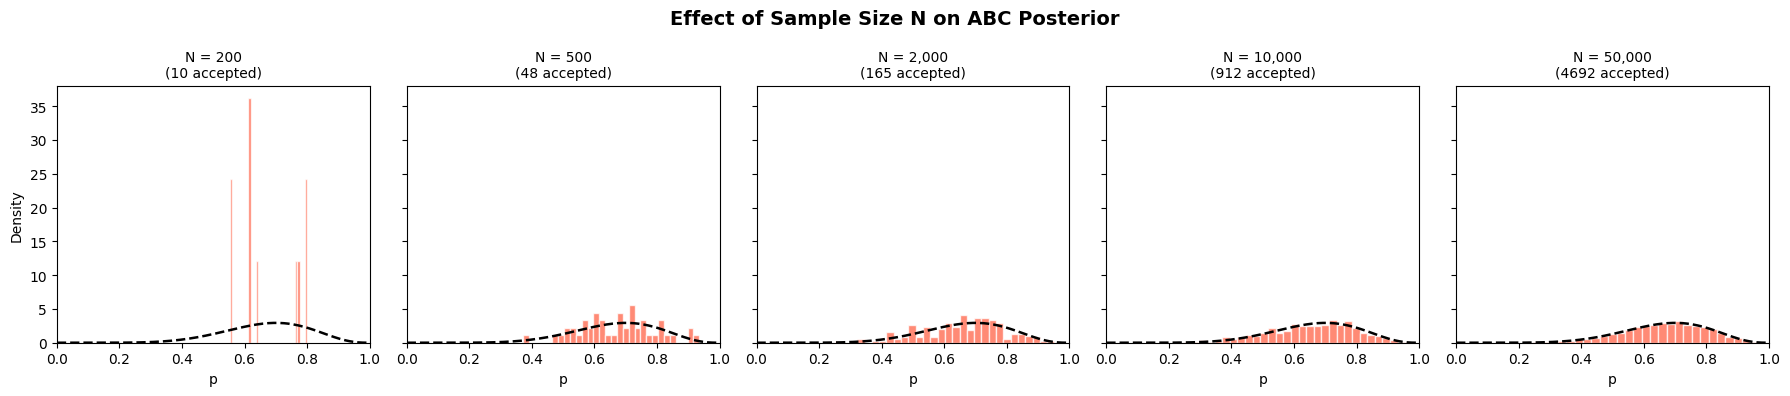

In [16]:
sample_sizes = [200, 500, 2000, 10000, 50000]
true_mean = 8 / 12   # analytical posterior mean

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(18, 4), sharey=True)
fig.suptitle("Effect of Sample Size N on ABC Posterior", fontsize=14, fontweight="bold")

for ax, N_val in zip(axes, sample_sizes):
    p_samp = np.random.beta(1, 1, size=N_val)
    x_samp = np.random.binomial(n=10, p=p_samp)
    post   = p_samp[x_samp == observed]

    ax.hist(post, bins=30, density=True, color="tomato", alpha=0.75, edgecolor="white")
    ax.plot(p_grid, analytical, "k--", linewidth=1.8)
    ax.set_title(f"N = {N_val:,}\n({len(post)} accepted)", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_xlabel("p")

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()

---
## Task 1: Change the prior

Replace the uniform prior `Beta(1,1)` with an **informative prior** `Beta(2, 5)` (biased towards low values of $p$). 
- How does the posterior change?
- What is the analytical posterior now? *(Hint: it's still a Beta distribution!)*

In [17]:
N = 20000
observed = 7

# TODO: change the prior parameters below
prior_ex1 = np.random.beta(2, 5, size=N)      # <-- try different values!
x_ex1     = np.random.binomial(n=10, p=prior_ex1)
post_ex1  = prior_ex1[x_ex1 == observed]

# TODO: update the analytical posterior to match your prior
# analytical_ex1 = stats.beta(?, ?)

print(f"Accepted: {len(post_ex1)},  mean = {post_ex1.mean():.4f}")

Accepted: 689,  mean = 0.5340


## Task 2: Change the observed data

Suppose you observed **3 heads** instead of 7. Modify `observed` and re-run the algorithm.
- In which direction does the posterior shift?
- Does the acceptance rate change? Why?

In [18]:
N = 10000
observed_ex2 = 3   # <-- change this!

prior_ex2 = np.random.beta(1, 1, size=N)
x_ex2     = np.random.binomial(n=10, p=prior_ex2)
post_ex2  = prior_ex2[x_ex2 == observed_ex2]

print(f"Accepted: {len(post_ex2)},  acceptance rate: {len(post_ex2)/N:.1%}")
print(f"Posterior mean: {post_ex2.mean():.4f}")

Accepted: 947,  acceptance rate: 9.5%
Posterior mean: 0.3306


## Task 3: More flips

Increase the number of coin flips from 10 to **50**, keeping the proportion of heads the same (`observed = 35`).
- What happens to the acceptance rate?
- What happens to the posterior width (uncertainty)?
- What does this tell you about the **curse of dimensionality** in ABC?

In [19]:
N        = 50000
n_flips  = 50      # <-- change number of flips
observed_ex3 = 35  # <-- 70% heads, same proportion as before

prior_ex3 = np.random.beta(1, 1, size=N)
x_ex3     = np.random.binomial(n=n_flips, p=prior_ex3)
post_ex3  = prior_ex3[x_ex3 == observed_ex3]

print(f"Accepted: {len(post_ex3)},  acceptance rate: {len(post_ex3)/N:.2%}")
print(f"Posterior std: {post_ex3.std():.4f}  (compare to original: {posterior.std():.4f})")

Accepted: 953,  acceptance rate: 1.91%
Posterior std: 0.0638  (compare to original: 0.1369)
